# 02b - LLM Triple Extraction with MinIE-style Annotations (ContraDoc)

Variant of notebook 02 with a richer extraction schema. Predicates are now expressed in their **affirmative, certain** form, and polarity / modality / attribution / quantity are captured as separate fields on each `Triple` rather than baked into the predicate string. This is motivated by the iText2KG trial (see `final-report/itext2kg_trial.tex`) and by MinIE (Gashteovski et al. 2017).

**Why a sibling notebook**
- Keeps notebook 02 (free-form predicate baseline) intact for downstream comparison.
- Output goes to a separate file so 03 / 04 can ingest either variant.

**Inputs**
- `data/processed/ContraDoc/ContraDoc.csv`
- `data/processed/ContraDoc/findability.json` - restricts the YES sample to docs whose evidence and ref sentences are all findable in the document text and not self-referencing (notebook 01 EDA).

**Output:** `data/processed/ContraDoc/triples_minie.jsonl` - one JSON object per document. Each triple now carries `polarity`, `polarity_marker`, `modality`, `modality_marker`, `attribution`, `quantity` in addition to `(s, p, o)`.

**Model:** configured via `settings.llm_model_openai_mini` in `config.py` (the cheap-tier OpenAI model used for this budget-constrained MinIE variant).

**Downstream consumers**
- `03_insert_to_neo4j_ContraDoc.ipynb` (or `03b`) - persists the new fields as `:RELATION` edge properties so RQ1 patterns can filter on polarity flips.
- `06_NLI_ContraDoc.ipynb` - still pairs verbatim `source_text` sentences (unchanged).


In [1]:
import json
from pathlib import Path

import pandas as pd
from ftfy import fix_text
from pydantic import BaseModel, Field
from tqdm import tqdm
from typing import Literal

from config import MODEL_PRICING, settings
from utils import init_extraction_llm, resolve_gold_sentence, usage_from_raw

INPUT_PATH = Path("data/processed/ContraDoc/ContraDoc.csv")
BALANCED_PATH = Path("data/processed/ContraDoc/balanced_sample.json")
OUTPUT_PATH = Path("data/processed/ContraDoc/triples_minie.jsonl")
USAGE_PATH = Path("data/processed/ContraDoc/triples_minie_usage.jsonl")


## Structured-output schema

The LLM returns a list of sentences in document order, each with its 1-indexed `sentence_id`, verbatim `source_text`, and a (possibly empty) list of `(s, p, o)` triples extracted from that sentence.

In [2]:
class Triple(BaseModel):
    s: str = Field(
        description=(
            "Subject - noun phrase, with pronouns and bare definites resolved "
            "to their antecedent using document context."
        )
    )
    p: str = Field(
        description=(
            "Predicate - short verbal phrase. Express the relation in its "
            "AFFIRMATIVE, CERTAIN form. Do NOT include negation words "
            "('not', 'never') or modal/possibility words ('may', 'probably', "
            "'might') in the predicate; report those via the polarity / "
            "modality fields below. Use the surface form of the verb only "
            "(e.g. 'donate', 'born_in', 'manage_to_enter')."
        )
    )
    o: str = Field(
        description=(
            "Object - noun phrase, numeric value (use the placeholder 'Q' if "
            "quantity is annotated below), date, or short complement."
        )
    )

    polarity: Literal["+", "-"] = Field(
        default="+",
        description=(
            "'+' if the relation is asserted positively, '-' if the sentence "
            "negates it ('not', 'never', 'no', 'none', 'nothing')."
        ),
    )
    polarity_marker: str | None = Field(
        default=None,
        description=(
            "The exact negation word from the source sentence when polarity "
            "is '-' (e.g. 'not', 'never'). None when polarity is '+'."
        ),
    )
    modality: Literal["CT", "PS"] = Field(
        default="CT",
        description=(
            "'CT' (certain) by default. 'PS' (possible) if the relation is "
            "hedged with modals ('may', 'might', 'could', 'should', 'would'),"
            " adverbs ('probably', 'possibly', 'maybe', 'likely'), or "
            "infinitive phrases ('is going to', 'plans to', 'intends to')."
        ),
    )
    modality_marker: str | None = Field(
        default=None,
        description=(
            "The exact possibility word/phrase from the source sentence when "
            "modality is 'PS' (e.g. 'probably', 'may'). None when modality "
            "is 'CT'."
        ),
    )
    attribution: str | None = Field(
        default=None,
        description=(
            "Supplier of information when the claim is reported speech, "
            "belief, or attributed via 'according to'. E.g. for 'Pinocchio "
            "believes that Superman was born on Krypton' the triple "
            "(Superman, born_on, Krypton) has attribution='Pinocchio'. None "
            "for direct factual statements."
        ),
    )
    quantity: str | None = Field(
        default=None,
        description=(
            "Original surface form of any cardinal/quantity expression that "
            "has been replaced by the placeholder 'Q' in s or o. "
            "E.g. if o='Q cats' then quantity='9' (or 'all', 'almost 100', "
            "etc.). None if no quantity normalization was applied."
        ),
    )


class SentenceExtraction(BaseModel):
    sentence_id: int = Field(description="1-indexed sentence position within the document, in original order.")
    source_text: str = Field(
        description="Verbatim sentence text, exactly as it appears in the document. Do not paraphrase, normalize, or trim."
    )
    triples: list[Triple] = Field(
        description="All claim triples extracted from this sentence. Empty list if the sentence has no extractable claim."
    )
    is_evidence: bool = Field(
        default=False,
        description="True on the ONE sentence matching the Evidence metadata (YES docs only). False for all other sentences and for every sentence in NO docs.",
    )
    ref_index: int | None = Field(
        default=None,
        description="0-based index into the Reference sentences list, set on the sentence matching that Reference (YES docs only). None otherwise.",
    )


class DocumentExtraction(BaseModel):
    sentences: list[SentenceExtraction]


## LLM client and prompt

Model and API key both pulled from `config.settings`. Change `llm_model` in `config.py` to swap models without touching this notebook.

In [3]:
import time as _time

SYSTEM_PROMPT = """You are an information extractor. Given a document, split it into sentences and extract all claim triples (subject, predicate, object) per sentence, along with semantic annotations on each triple.

Rules for the core triple:
- Resolve pronouns and bare definites to their antecedents using surrounding context (e.g., 'she' -> 'Mrs. Tittlemouse'; 'the company' -> 'Microsoft Israel').
- Subjects and objects should be noun phrases, numeric values, or dates - concise but specific.
- Express the predicate in its AFFIRMATIVE, CERTAIN form. Do NOT bake polarity, modality, or attribution into the predicate string. For example, from "Faust did not make a deal with the Devil", extract p='make_a_deal_with' with polarity='-' and polarity_marker='not'. From "Superman may have been born on Krypton", extract p='born_on' with modality='PS' and modality_marker='may'.

Rules for semantic annotations (per triple):
- polarity: '+' for affirmed claims, '-' if the sentence negates them. polarity_marker holds the exact negation word ('not', 'never', 'no'); None when '+'.
- modality: 'CT' (certain) by default. 'PS' (possible) for hedged claims with modals ('may', 'might', 'could'), adverbs ('probably', 'possibly', 'likely', 'maybe'), or infinitive verbs ('is going to', 'plans to', 'intends to'). modality_marker holds the exact word/phrase; None when 'CT'.
- attribution: when a claim is REPORTED through a believer/sayer ('X believes that Y', 'according to X, Y', 'X said Y'), set attribution=X and put the inner claim Y as the triple. For direct facts, attribution=None.
- quantity: when the subject or object contains a cardinal/quantity expression ('9 cats', 'all cats', 'almost 100 cats'), replace it with the placeholder 'Q' in s/o and put the original surface form in quantity ('9', 'all', 'almost 100'). Skip when there is no quantity to normalize.

Document-structure rules (STRICT - violations break the downstream pipeline):
- EXACTLY ONE sentence per `SentenceExtraction` entry. Never bundle two or more sentences into a single `source_text`, even when they share a topic, sit inside the same paragraph, or appear back-to-back across a quote ending. If the document contains "X. Y." back to back, you MUST produce two separate entries, not one entry with `source_text="X. Y."`.
- A sentence ends at the FIRST '.', '!', '?', or closing-quote-after-punctuation ('."', '?"', '!"', '."', '?"', etc.). Whatever follows that boundary starts a new sentence. The only exception is abbreviations ('Mr.', 'Mrs.', 'Dr.', 'U.S.', 'St.', etc.) which do NOT end a sentence.
- `source_text` is verbatim from the document - matching character-for-character including original punctuation, casing, and whitespace WITHIN the sentence. Do not paraphrase, trim, normalize, or fuse adjacent sentences by dropping the space between them.
- Sentences appear in document order. A sentence with no extractable claim STILL appears as its own entry with `triples=[]` so `sentence_id` stays aligned with the document.

Sentence-segmentation example. For the source span:
  Chapter 6 analyses the resistance Hallery's concept inspires. Chapter 7 praises Nietzsche.
CORRECT output (two entries):
  [{"sentence_id": 12, "source_text": "Chapter 6 analyses the resistance Hallery's concept inspires.", ...},
   {"sentence_id": 13, "source_text": "Chapter 7 praises Nietzsche.", ...}]
INCORRECT output (forbidden - bundles two sentences):
  [{"sentence_id": 12, "source_text": "Chapter 6 analyses the resistance Hallery's concept inspires. Chapter 7 praises Nietzsche.", ...}]

Rules for contradiction metadata (only when the user message includes an Evidence/Reference block):
- Set `is_evidence=true` on EXACTLY ONE output sentence - the one whose `source_text` matches the provided Evidence text verbatim. All others MUST have `is_evidence=false`. The matching sentence must be a single sentence; do not bundle the Evidence with neighbors to make is_evidence=true cover both.
- For each Reference [i] in the provided list, set `ref_index=i` on the ONE output sentence whose `source_text` matches that Reference text verbatim. All other sentences MUST have `ref_index=null`.
- Sentences tagged `is_evidence=true` or `ref_index=i` MUST each carry at least one triple - these are the semantically important sentences.
- If the user message does NOT include a contradiction metadata block, every sentence must have `is_evidence=false` and `ref_index=null`.
"""


# Active extraction model, set in config.py / overridable via .env.
LLM_MODEL = settings.llm_model_extraction

# Reasoning / extended-thinking effort for models that support it.
#   None  -> provider default (works for all models, including non-reasoning).
#   "low" / "medium" / "high":
#     claude-*     -> thinking={"type": "enabled", "budget_tokens": 1024 / 4096 / 16000}
#     o1*/o3*/o4*  -> reasoning_effort passed through to ChatOpenAI
REASONING_EFFORT: str | None = None

# 16k output cap. Largest seen during pilot was ~6.5k; 16k gives headroom for
# longer or more verbosely-chunked docs without paying for unused budget.
MAX_TOKENS = 16384

# Retry budget for transient parsed=None from langchain (tool-call parsing
# is occasionally flaky on opus-4-7 - observed ~1 / 10 docs in pilot).
EXTRACT_MAX_RETRIES = 3

llm_kwargs: dict = {
    "openai_key": settings.openai_api_key,
    "anthropic_key": settings.anthropic_api_key,
    "max_tokens": MAX_TOKENS,
}
# claude-opus-4-7 (and likely other adaptive-thinking claude models) deprecate
# `temperature`; pass it only for providers that still accept it.
if not LLM_MODEL.startswith("claude-"):
    llm_kwargs["temperature"] = 0
if REASONING_EFFORT is not None:
    if LLM_MODEL.startswith("claude-"):
        _budget = {"low": 1024, "medium": 4096, "high": 16000}[REASONING_EFFORT]
        llm_kwargs["thinking"] = {"type": "enabled", "budget_tokens": _budget}
    elif LLM_MODEL.startswith(("o1", "o3", "o4")):
        llm_kwargs["reasoning_effort"] = REASONING_EFFORT

llm = init_extraction_llm(LLM_MODEL, **llm_kwargs)
# include_raw=True so we can read usage_metadata off the AIMessage and bill each call.
extractor = llm.with_structured_output(DocumentExtraction, include_raw=True)


def extract_document(
    text: str,
    evidence: str | None = None,
    refs: list[str] | None = None,
    max_retries: int = EXTRACT_MAX_RETRIES,
) -> tuple[DocumentExtraction, dict]:
    """Returns (parsed extraction, usage dict). Retries up to max_retries on
    transient parsed=None failures (langchain tool-call parsing is flaky on
    opus-4-7). Raises RuntimeError after retries are exhausted so the fullrun
    loop's try/except can log + skip cleanly.
    """
    user_msg = f"Document:\n{text}"
    if evidence is not None:
        user_msg += (
            "\n\n--- Contradiction metadata ---"
            "\nEvidence sentence (tag the matching output sentence with is_evidence=true; extract at least one triple from it):"
            f"\n{evidence}"
        )
    if refs:
        user_msg += (
            "\n\nReference sentence(s) that the Evidence contradicts "
            "(tag each matching output sentence with the correct ref_index; extract at least one triple from each):"
        )
        for i, ref in enumerate(refs):
            user_msg += f"\n  [{i}] {ref}"

    last_stop_reason = None
    for attempt in range(1, max_retries + 1):
        out = extractor.invoke(
            [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_msg},
            ]
        )
        parsed = out["parsed"]
        if parsed is not None:
            return parsed, usage_from_raw(out["raw"], LLM_MODEL)
        last_stop_reason = getattr(out["raw"], "response_metadata", {}).get("stop_reason")
        if attempt < max_retries:
            _time.sleep(2)
    raise RuntimeError(
        f"Structured-output parsing returned None after {max_retries} attempts (last stop_reason={last_stop_reason})."
    )


## Load ContraDoc

In [4]:
contra_df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(contra_df)} documents from {INPUT_PATH}")
print(f"  YES: {(contra_df['contradiction'] == 'YES').sum()}  NO: {(contra_df['contradiction'] == 'NO').sum()}")

balanced = json.loads(BALANCED_PATH.read_text(encoding="utf-8"))
balanced_ids = set(balanced["doc_ids"])
print(f"Balanced sample: {len(balanced_ids)} YES doc_ids (notebook 01)")

# Restrict to the canonical balanced YES sample. No NO docs - the negative
# signal for downstream NLI comes from in-doc non-gold sentence pairings.
contra_df = contra_df[contra_df["id"].astype(str).isin(balanced_ids)].reset_index(drop=True)
print(f"To extract: {len(contra_df)} docs")
contra_df.head(2)


Loaded 891 documents from data\processed\ContraDoc\ContraDoc.csv
  YES: 449  NO: 442
Balanced sample: 150 YES doc_ids (notebook 01)
To extract: 150 docs


,id,contradiction,doc_type,scope,contra_plug,contra_type,evidence,ref_sentences,text
0,3488771854_6,YES,story,local,Insert,Content|Emotion/Mood/Feeling,Sylvia celebrates her brother Owen's death.,Sylvia leaves her father's house to mourn her ...,"The play opens with the recruiter, Captain Plu..."
1,3488771854_8,YES,story,global,Replace,Relation,Kite abducts 'him' for Brazen while Plume duel...,"The play opens with the recruiter, Captain Plu...","The play opens with the recruiter, Captain Plu..."


## Sanity check on a single document

Run extraction on the first document to confirm the prompt and schema behave before launching the full pass.

In [5]:
sample = contra_df[contra_df["contradiction"] == "YES"].iloc[0]
text = fix_text(sample["text"])
evidence = fix_text(sample["evidence"])
refs = [fix_text(r) for r in sample["ref_sentences"].split("|")]
result, usage = extract_document(text, evidence=evidence, refs=refs)

print(f"doc_id={sample['id']}  contradiction={sample['contradiction']}  model={LLM_MODEL}")
print(f"sentences extracted: {len(result.sentences)}")
print(f"total triples:      {sum(len(s.triples) for s in result.sentences)}")
print(f"tokens (in/out/total): {usage['input_tokens']:,} / {usage['output_tokens']:,} / {usage['total_tokens']:,}")
print(f"cost (in/out/total):   ${usage['input_cost']:.4f} / ${usage['output_cost']:.4f} / ${usage['total_cost']:.4f}")

ev = next((s for s in result.sentences if s.is_evidence), None)
ref_ids_by_idx = {s.ref_index: s.sentence_id for s in result.sentences if s.ref_index is not None}
print(f"tagged is_evidence  sentence_id: {ev.sentence_id if ev else None}")
print(f"tagged ref sentence_ids by index: {ref_ids_by_idx}")
print()


def fmt_triple(t: Triple) -> str:
    """Compact one-liner including non-default annotations."""
    extras = []
    if t.polarity == "-":
        extras.append(f"polarity=-:{t.polarity_marker}")
    if t.modality == "PS":
        extras.append(f"modality=PS:{t.modality_marker}")
    if t.attribution is not None:
        extras.append(f"attribution={t.attribution}")
    if t.quantity is not None:
        extras.append(f"quantity={t.quantity}")
    suffix = f"  [{', '.join(extras)}]" if extras else ""
    return f"({t.s}, {t.p}, {t.o}){suffix}"


for s in result.sentences[:8]:
    tag = "EVIDENCE" if s.is_evidence else (f"REF[{s.ref_index}]" if s.ref_index is not None else "        ")
    print(f"[{s.sentence_id}] {tag}  {s.source_text[:120]}")
    for t in s.triples:
        print(f"            -> {fmt_triple(t)}")

print()
print("=== Gold pair triples (with annotations) ===")
if ev is not None:
    print(f"EVIDENCE [{ev.sentence_id}]: {ev.source_text}")
    for t in ev.triples:
        print(f"  -> {fmt_triple(t)}")
for sid in sorted(ref_ids_by_idx.values()):
    s = next(x for x in result.sentences if x.sentence_id == sid)
    print(f"REF      [{s.sentence_id}]: {s.source_text}")
    for t in s.triples:
        print(f"  -> {fmt_triple(t)}")


doc_id=3488771854_6  contradiction=YES  model=claude-opus-4-7
sentences extracted: 25
total triples:      67
tokens (in/out/total): 5,127 / 4,116 / 9,243
cost (in/out/total):   $0.0256 / $0.1029 / $0.1285
tagged is_evidence  sentence_id: 8
tagged ref sentence_ids by index: {0: 10}

[1]           The play opens with the recruiter, Captain Plume's Sergeant Kite, recruiting in the town of Shrewsbury.
            -> (Sergeant Kite, recruiting_in, Shrewsbury)
            -> (Sergeant Kite, is_sergeant_of, Captain Plume)
[2]           Plume arrives, in love with Sylvia, closely followed by Worthy, a local gentleman who is in love with Sylvia's cousin Me
            -> (Plume, in_love_with, Sylvia)
            -> (Worthy, in_love_with, Melinda)
            -> (Melinda, is_cousin_of, Sylvia)
[3]           Worthy asked Melinda to become his mistress a year previously, as he believed her to be of inadequate fortune to marry.
            -> (Worthy, asked_to_become_mistress, Melinda)
            

In [6]:
result.sentences

[SentenceExtraction(sentence_id=1, source_text="The play opens with the recruiter, Captain Plume's Sergeant Kite, recruiting in the town of Shrewsbury.", triples=[Triple(s='Sergeant Kite', p='recruiting_in', o='Shrewsbury', polarity='+', polarity_marker=None, modality='CT', modality_marker=None, attribution=None, quantity=None), Triple(s='Sergeant Kite', p='is_sergeant_of', o='Captain Plume', polarity='+', polarity_marker=None, modality='CT', modality_marker=None, attribution=None, quantity=None)], is_evidence=False, ref_index=None),
 SentenceExtraction(sentence_id=2, source_text="Plume arrives, in love with Sylvia, closely followed by Worthy, a local gentleman who is in love with Sylvia's cousin Melinda.", triples=[Triple(s='Plume', p='in_love_with', o='Sylvia', polarity='+', polarity_marker=None, modality='CT', modality_marker=None, attribution=None, quantity=None), Triple(s='Worthy', p='in_love_with', o='Melinda', polarity='+', polarity_marker=None, modality='CT', modality_marker=No

In [7]:
sample["evidence"]

"Sylvia celebrates her brother Owen's death."

In [8]:
sample["contra_type"]

'Content|Emotion/Mood/Feeling'

In [9]:
sample

id                                                    3488771854_6
contradiction                                                  YES
doc_type                                                     story
scope                                                        local
contra_plug                                                 Insert
contra_type                           Content|Emotion/Mood/Feeling
evidence               Sylvia celebrates her brother Owen's death.
ref_sentences    Sylvia leaves her father's house to mourn her ...
text             The play opens with the recruiter, Captain Plu...
Name: 0, dtype: str

## Run extraction on the full corpus

Resumable: reads any existing `triples.jsonl` and skips documents already done. Output is appended one JSON object per document, flushed every row, so an interrupted run can resume mid-corpus.

Failed extractions are logged and skipped; rerunning the cell will retry them.

In [10]:
# Re-run this cell repeatedly to extract one chunk at a time. Done docs are
# skipped via the existing OUTPUT_PATH resume. Set CHUNK_SIZE = None to run
# everything remaining in a single pass.
CHUNK_SIZE: int | None = None

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

done_ids: set[str] = set()
if OUTPUT_PATH.exists():
    with OUTPUT_PATH.open(encoding="utf-8") as f:
        for line in f:
            done_ids.add(json.loads(line)["doc_id"])

# Replay the usage file to show cumulative spend before this chunk starts.
cum_cost = 0.0
cum_in = 0
cum_out = 0
if USAGE_PATH.exists():
    with USAGE_PATH.open(encoding="utf-8") as uf:
        for line in uf:
            u = json.loads(line)
            cum_cost += u.get("total_cost", 0.0)
            cum_in += u.get("input_tokens", 0)
            cum_out += u.get("output_tokens", 0)

print(f"Already extracted: {len(done_ids)} docs")
print(f"Cumulative spend:  ${cum_cost:.4f}  ({cum_in:,} in + {cum_out:,} out)")

remaining = contra_df[~contra_df["id"].astype(str).isin(done_ids)].reset_index(drop=True)
this_chunk = remaining if CHUNK_SIZE is None else remaining.head(CHUNK_SIZE)
print(f"This chunk:        {len(this_chunk)} docs (of {len(remaining)} remaining)  model={LLM_MODEL}")
print()

chunk_cost = 0.0
chunk_in = 0
chunk_out = 0

with OUTPUT_PATH.open("a", encoding="utf-8") as f, USAGE_PATH.open("a", encoding="utf-8") as uf:
    for row in tqdm(this_chunk.itertuples(index=False), total=len(this_chunk)):
        # Repair UTF-8-as-Latin-1 mojibake before sending to the LLM. Some
        # ContraDoc rows have control bytes (\x80, \x93) that confuse the
        # tool-call JSON output. Fix consistently across text/evidence/refs
        # so the gold-resolution matcher still aligns.
        text = fix_text(row.text)
        evidence_clean = fix_text(row.evidence) if row.contradiction == "YES" else None
        refs_clean: list[str] = (
            [fix_text(r) for r in row.ref_sentences.split("|")]
            if row.contradiction == "YES" else []
        )

        try:
            if row.contradiction == "YES":
                result, usage = extract_document(text, evidence=evidence_clean, refs=refs_clean)
            else:
                result, usage = extract_document(text)
        except Exception as exc:
            print(f"FAILED doc_id={row.id}: {type(exc).__name__}: {exc}")
            continue

        gold_evidence_id = None
        gold_ref_ids: list[int] = []
        resolution_notes: list[str] = []

        if row.contradiction == "YES":
            ev_tagged = next((s for s in result.sentences if s.is_evidence), None)
            gold_evidence_id, ev_res = resolve_gold_sentence(evidence_clean, ev_tagged, result.sentences)
            if ev_res != "llm_tag":
                resolution_notes.append(f"evidence={ev_res}")

            ref_by_index = {s.ref_index: s for s in result.sentences if s.ref_index is not None}
            for i, ref_text in enumerate(refs_clean):
                sid, ref_res = resolve_gold_sentence(ref_text, ref_by_index.get(i), result.sentences)
                if sid is not None and sid not in gold_ref_ids:
                    gold_ref_ids.append(sid)
                if ref_res != "llm_tag":
                    resolution_notes.append(f"ref[{i}]={ref_res}")

            if resolution_notes:
                print(f"INFO doc_id={row.id}: {', '.join(resolution_notes)}")
            if gold_evidence_id is None:
                print(f"WARN doc_id={row.id}: evidence unmatched (not in LLM output even by fuzzy)")
            if not gold_ref_ids:
                print(f"WARN doc_id={row.id}: no refs matched")

        record = {
            "doc_id": str(row.id),
            "contradiction": row.contradiction,
            "doc_type": row.doc_type,
            "scope": row.scope,
            "contra_plug": row.contra_plug,
            "contra_type": row.contra_type,
            "evidence": evidence_clean,
            "ref_sentences": "|".join(refs_clean) if refs_clean else row.ref_sentences,
            "gold_evidence_sentence_id": gold_evidence_id,
            "gold_ref_sentence_ids": gold_ref_ids,
            "sentences": [s.model_dump() for s in result.sentences],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()

        usage_record = {"doc_id": str(row.id), "contradiction": row.contradiction, **usage}
        uf.write(json.dumps(usage_record, ensure_ascii=False) + "\n")
        uf.flush()

        chunk_cost += usage["total_cost"]
        chunk_in += usage["input_tokens"]
        chunk_out += usage["output_tokens"]

print()
print(f"Chunk done:        ${chunk_cost:.4f}  ({chunk_in:,} in + {chunk_out:,} out)")
print(f"Cumulative spend:  ${cum_cost + chunk_cost:.4f}")
print(f"Still remaining:   {len(remaining) - len(this_chunk)} docs")
print(f"Output: {OUTPUT_PATH.resolve()}")
print(f"Usage:  {USAGE_PATH.resolve()}")


Already extracted: 150 docs
Cumulative spend:  $23.8237  (846,045 in + 783,739 out)
This chunk:        0 docs (of 0 remaining)  model=claude-opus-4-7



0it [00:00, ?it/s]

0it [00:00, ?it/s]


Chunk done:        $0.0000  (0 in + 0 out)
Cumulative spend:  $23.8237
Still remaining:   0 docs
Output: D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\triples_minie.jsonl
Usage:  D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\triples_minie_usage.jsonl


## Verify output

In [11]:
records = [json.loads(line) for line in OUTPUT_PATH.open(encoding="utf-8")]
n_sentences = sum(len(r["sentences"]) for r in records)
n_triples = sum(sum(len(s["triples"]) for s in r["sentences"]) for r in records)

print(f"Documents extracted: {len(records)} / {len(contra_df)}")
print(f"Total sentences:    {n_sentences}")
print(f"Total triples:      {n_triples}")
print(f"Avg triples / doc:  {n_triples / max(len(records), 1):.1f}")
print()


def triples_at(rec, sid):
    if sid is None:
        return []
    for s in rec["sentences"]:
        if s["sentence_id"] == sid:
            return s["triples"]
    return []


yes_records = [r for r in records if r["contradiction"] == "YES"]
gold_matched = [r for r in yes_records if r["gold_evidence_sentence_id"] is not None and r["gold_ref_sentence_ids"]]
gold_usable = [
    r for r in gold_matched if triples_at(r, r["gold_evidence_sentence_id"]) and any(triples_at(r, sid) for sid in r["gold_ref_sentence_ids"])
]

print(f"YES docs: {len(yes_records)}")
print(f"  with both evidence + ref sentence_ids matched: {len(gold_matched)}")
print(f"  AND >= 1 triple at evidence and at >= 1 ref:   {len(gold_usable)}")
print()

if gold_usable:
    r = gold_usable[0]
    ev_t = triples_at(r, r["gold_evidence_sentence_id"])
    ref_t = [t for sid in r["gold_ref_sentence_ids"] for t in triples_at(r, sid)]
    print(f"Sample usable gold pair (doc_id={r['doc_id']}):")
    print(f"  evidence triples ({len(ev_t)}):")
    for t in ev_t:
        print(f"    {t}")
    print(f"  ref triples ({len(ref_t)}):")
    for t in ref_t:
        print(f"    {t}")

Documents extracted: 150 / 150
Total sentences:    5651
Total triples:      9189
Avg triples / doc:  61.3

YES docs: 150
  with both evidence + ref sentence_ids matched: 123
  AND >= 1 triple at evidence and at >= 1 ref:   123

Sample usable gold pair (doc_id=3488771854_6):
  evidence triples (1):
    {'s': 'Sylvia', 'p': 'celebrates', 'o': "her brother Owen's death", 'polarity': '+', 'polarity_marker': None, 'modality': 'CT', 'modality_marker': None, 'attribution': None, 'quantity': None}
  ref triples (2):
    {'s': 'Sylvia', 'p': 'leaves', 'o': "her father's house", 'polarity': '+', 'polarity_marker': None, 'modality': 'CT', 'modality_marker': None, 'attribution': None, 'quantity': None}
    {'s': 'Sylvia', 'p': 'mourn', 'o': "her brother Owen's death", 'polarity': '+', 'polarity_marker': None, 'modality': 'CT', 'modality_marker': None, 'attribution': None, 'quantity': None}


## Pilot validation

Three checks that run for free on the saved output and flag systematic issues
before scaling to 150 docs:

- **Resolution tags** - was the LLM able to self-tag the gold evidence/ref
  sentences (`llm_tag`), or did we have to fall back to fuzzy match
  (`fuzzy_recovered`, `fuzzy_override_bad_tag`), or fail entirely (`unmatched`)?
- **MinIE annotation rate** - what fraction of triples carry polarity='-',
  modality='PS', attribution, quantity? Sanity-checks the prompt is using the
  schema rather than dropping it.
- **Token overlap** - cheap hallucination heuristic: do the content words of
  each `(s, p, o)` appear in the source sentence?
- **Per-doc spot check** - prints all 10 docs' evidence + ref triples for
  manual eyeball.

In [12]:
from collections import Counter
from types import SimpleNamespace
import statistics

# ---- Resolution tag distribution (re-resolve on saved data) ----
ev_tags, ref_tags = Counter(), Counter()
for r in records:
    if r["contradiction"] != "YES":
        continue
    sents = [SimpleNamespace(sentence_id=s["sentence_id"], source_text=s["source_text"]) for s in r["sentences"]]
    ev_tagged = next(
        (SimpleNamespace(sentence_id=s["sentence_id"], source_text=s["source_text"])
         for s in r["sentences"] if s["is_evidence"]),
        None,
    )
    _, ev_tag = resolve_gold_sentence(r["evidence"], ev_tagged, sents)
    ev_tags[ev_tag] += 1
    ref_by_idx = {
        s["ref_index"]: SimpleNamespace(sentence_id=s["sentence_id"], source_text=s["source_text"])
        for s in r["sentences"] if s["ref_index"] is not None
    }
    for i, ref_text in enumerate(r["ref_sentences"].split("|")):
        _, ref_tag = resolve_gold_sentence(ref_text, ref_by_idx.get(i), sents)
        ref_tags[ref_tag] += 1

print("Evidence resolution tags:")
for tag in ["llm_tag", "fuzzy_recovered", "fuzzy_override_bad_tag", "unmatched"]:
    print(f"  {tag:30s} {ev_tags.get(tag, 0)}")
print("Reference resolution tags:")
for tag in ["llm_tag", "fuzzy_recovered", "fuzzy_override_bad_tag", "unmatched"]:
    print(f"  {tag:30s} {ref_tags.get(tag, 0)}")

# ---- MinIE annotation distribution ----
all_triples = [(r, s, t) for r in records for s in r["sentences"] for t in s["triples"]]
n = len(all_triples)
print(f"\nTriples extracted: {n}")
if n:
    n_neg  = sum(1 for _, _, t in all_triples if t["polarity"] == "-")
    n_ps   = sum(1 for _, _, t in all_triples if t["modality"] == "PS")
    n_attr = sum(1 for _, _, t in all_triples if t["attribution"] is not None)
    n_qty  = sum(1 for _, _, t in all_triples if t["quantity"] is not None)
    print(f"  polarity='-':       {n_neg:4d} ({n_neg/n*100:.1f}%)")
    print(f"  modality='PS':      {n_ps:4d} ({n_ps/n*100:.1f}%)")
    print(f"  attribution!=None:  {n_attr:4d} ({n_attr/n*100:.1f}%)")
    print(f"  quantity!=None:     {n_qty:4d} ({n_qty/n*100:.1f}%)")

# ---- Hallucination via token overlap ----
def triple_overlap(t, src):
    src_low = src.lower()
    toks = []
    for fld in (t["s"], t["p"], t["o"]):
        for w in fld.replace("_", " ").lower().split():
            if w.isalpha() and len(w) > 2:
                toks.append(w)
    if not toks:
        return None
    return sum(1 for w in toks if w in src_low) / len(toks)

overlaps = []
for r, s, t in all_triples:
    o = triple_overlap(t, s["source_text"])
    if o is not None:
        overlaps.append((o, r["doc_id"], s["sentence_id"], s["source_text"], t))

ratios = [x[0] for x in overlaps]
if ratios:
    print(f"\nTriple<->source content-token overlap (n={len(ratios)}):")
    print(f"  mean:           {statistics.mean(ratios)*100:.1f}%")
    print(f"  median:         {statistics.median(ratios)*100:.1f}%")
    print(f"  >=80% overlap:  {sum(1 for r in ratios if r >= 0.8)}/{len(ratios)} ({sum(1 for r in ratios if r >= 0.8)/len(ratios)*100:.1f}%)")
    print(f"  <50% overlap:   {sum(1 for r in ratios if r < 0.5)}/{len(ratios)} ({sum(1 for r in ratios if r < 0.5)/len(ratios)*100:.1f}%)")
    print(f"\nLowest-overlap triples (eyeball for hallucination):")
    for o, did, sid, src, t in sorted(overlaps, key=lambda x: x[0])[:5]:
        print(f"  [{o*100:3.0f}%] doc={did} sid={sid}")
        print(f"     src   : {src[:140]}")
        print(f"     triple: ({t['s']}, {t['p']}, {t['o']})")

# ---- Per-doc gold pair spot check + unmatched diagnostics ----
print(f"\n{'='*70}")
print("Gold pair triples per doc (manual eyeball)")
print(f"{'='*70}")
for r in records:
    if r["contradiction"] != "YES":
        continue
    by_sid = {s["sentence_id"]: s for s in r["sentences"]}
    print(f"\ndoc_id={r['doc_id']}  contra_type={r['contra_type']}")

    if r["gold_evidence_sentence_id"] is None:
        print(f"  EVIDENCE: NOT MATCHED. Original: {r['evidence'][:140]}")
    else:
        ev_s = by_sid.get(r["gold_evidence_sentence_id"])
        print(f"  EVIDENCE [{ev_s['sentence_id']}]: {ev_s['source_text'][:140]}")
        for t in ev_s["triples"]:
            extras = []
            if t["polarity"] == "-": extras.append(f"-:{t['polarity_marker']}")
            if t["modality"] == "PS": extras.append(f"PS:{t['modality_marker']}")
            if t["attribution"]: extras.append(f"attr={t['attribution']}")
            if t["quantity"] is not None: extras.append(f"qty={t['quantity']}")
            suf = f"  [{', '.join(extras)}]" if extras else ""
            print(f"     -> ({t['s']}, {t['p']}, {t['o']}){suf}")

    if not r["gold_ref_sentence_ids"]:
        print(f"  REF: NOT MATCHED. Originals: {r['ref_sentences'][:200]}")
    else:
        for sid in r["gold_ref_sentence_ids"]:
            ref_s = by_sid.get(sid)
            if not ref_s:
                continue
            print(f"  REF      [{ref_s['sentence_id']}]: {ref_s['source_text'][:140]}")
            for t in ref_s["triples"]:
                extras = []
                if t["polarity"] == "-": extras.append(f"-:{t['polarity_marker']}")
                if t["modality"] == "PS": extras.append(f"PS:{t['modality_marker']}")
                if t["attribution"]: extras.append(f"attr={t['attribution']}")
                if t["quantity"] is not None: extras.append(f"qty={t['quantity']}")
                suf = f"  [{', '.join(extras)}]" if extras else ""
                print(f"     -> ({t['s']}, {t['p']}, {t['o']}){suf}")


Evidence resolution tags:
  llm_tag                        134
  fuzzy_recovered                0
  fuzzy_override_bad_tag         3
  unmatched                      13
Reference resolution tags:
  llm_tag                        136
  fuzzy_recovered                1
  fuzzy_override_bad_tag         3
  unmatched                      26

Triples extracted: 9189
  polarity='-':        497 (5.4%)
  modality='PS':       508 (5.5%)
  attribution!=None:  1232 (13.4%)
  quantity!=None:      581 (6.3%)

Triple<->source content-token overlap (n=9189):
  mean:           88.1%
  median:         100.0%
  >=80% overlap:  7047/9189 (76.7%)
  <50% overlap:   248/9189 (2.7%)

Lowest-overlap triples (eyeball for hallucination):
  [  0%] doc=3488771855_1 sid=3
     src   : Put in a crate, he is starved and ill-treated.
     triple: (Buck, ill-treated, )
  [  0%] doc=3489825769_11 sid=16
     src   : The former Virginia senator, after possibly seeing O'Malley making the rounds, did stand up and shake ha

## Plots

Visualize the extraction results: gold-sentence resolution rates, triple-count distribution, MinIE annotation coverage, and token overlap (hallucination heuristic). PNGs saved to `plots/02b_triples_extraction/`.

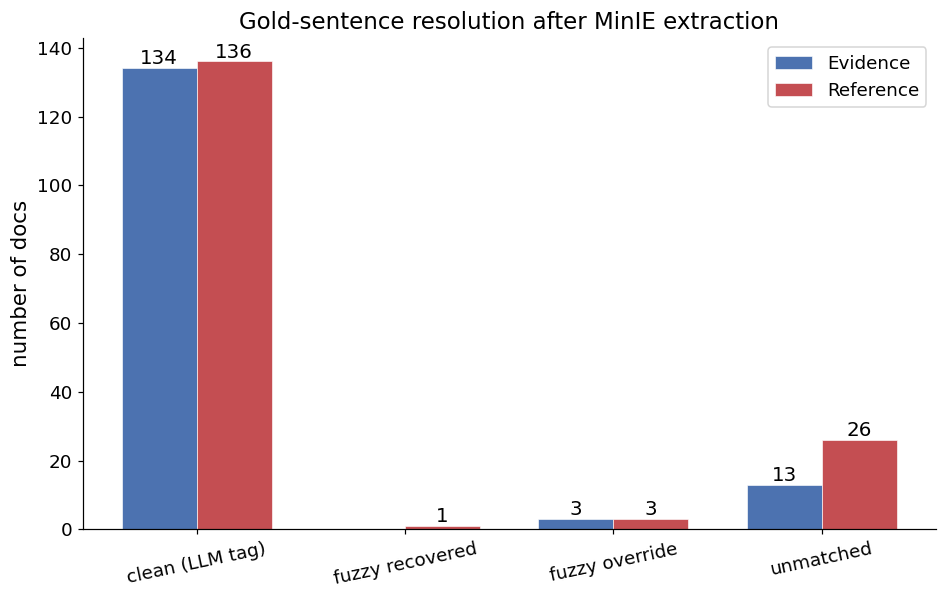

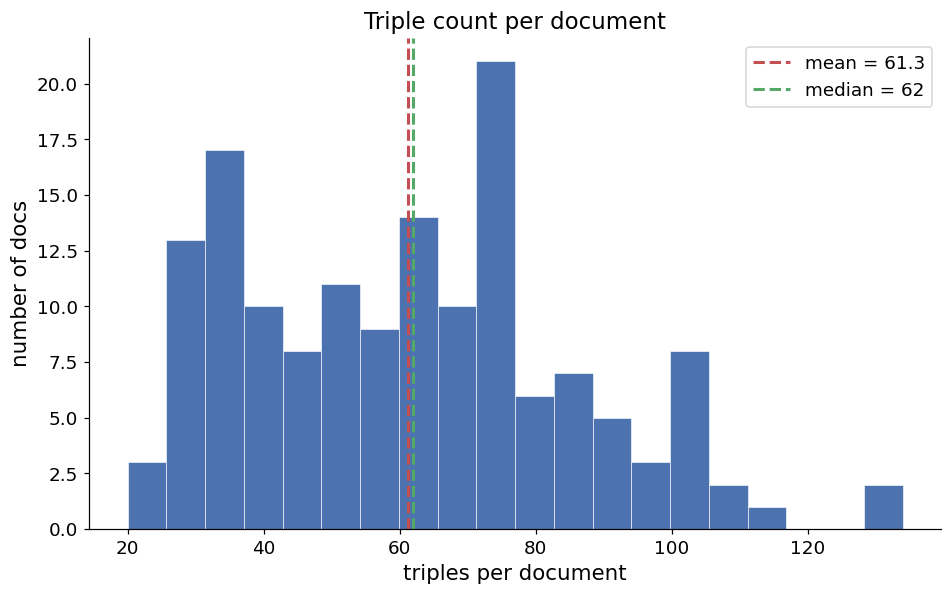

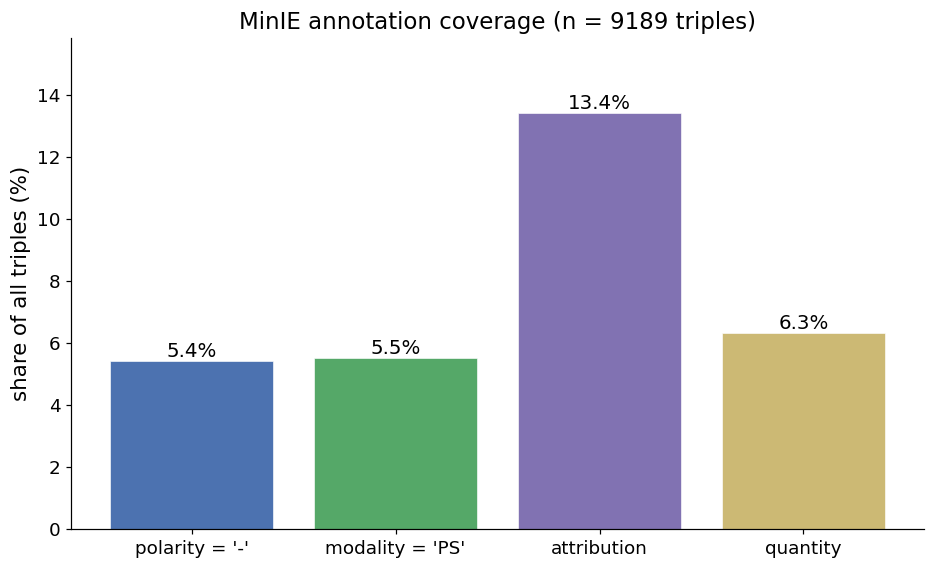

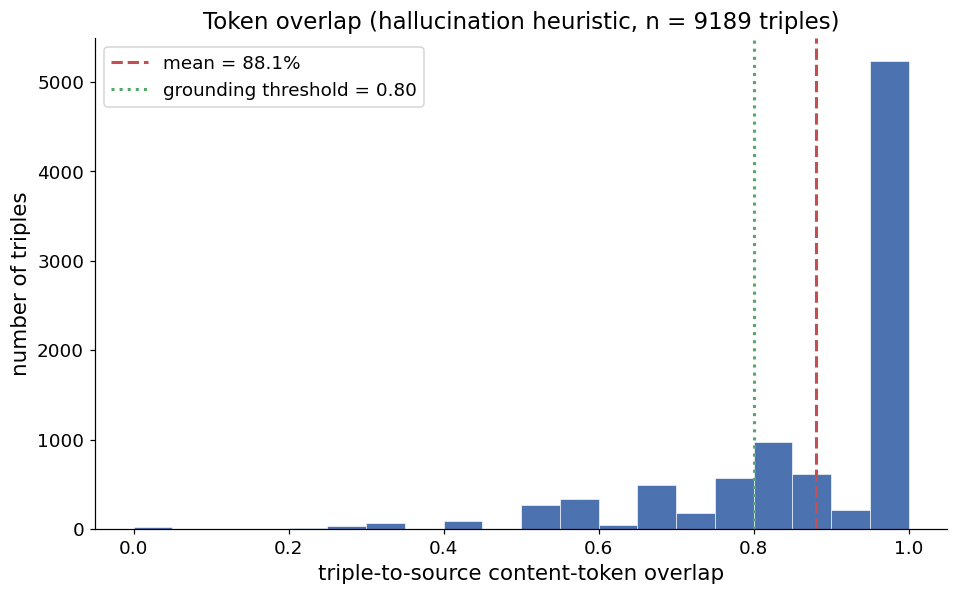

Saved 4 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\02b_triples_extraction


In [13]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = Path("plots/02b_triples_extraction")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"

# --- Plot 1: gold sentence resolution ---
tag_order = ["llm_tag", "fuzzy_recovered", "fuzzy_override_bad_tag", "unmatched"]
tag_labels = ["clean (LLM tag)", "fuzzy recovered", "fuzzy override", "unmatched"]
ev_counts = [ev_tags.get(t, 0) for t in tag_order]
ref_counts = [ref_tags.get(t, 0) for t in tag_order]
x = np.arange(len(tag_order))
w = 0.36
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.bar(x - w / 2, ev_counts, w, label="Evidence", color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.bar(x + w / 2, ref_counts, w, label="Reference", color=C_RED, edgecolor="white", linewidth=0.4)
for i, (e, r) in enumerate(zip(ev_counts, ref_counts)):
    if e:
        ax.text(i - w / 2, e, str(e), ha="center", va="bottom")
    if r:
        ax.text(i + w / 2, r, str(r), ha="center", va="bottom")
ax.set_xticks(x)
ax.set_xticklabels(tag_labels, rotation=12)
ax.set_ylabel("number of docs")
ax.set_title("Gold-sentence resolution after MinIE extraction")
ax.legend()
fig.savefig(PLOT_DIR / "resolution_tags.png")
plt.show()

# --- Plot 2: triples per doc ---
trip_per_doc = [sum(len(s["triples"]) for s in r["sentences"]) for r in records]
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.hist(trip_per_doc, bins=20, color=C_BLUE, edgecolor="white", linewidth=0.4)
mean_t = sum(trip_per_doc) / len(trip_per_doc)
sorted_t = sorted(trip_per_doc)
med_t = sorted_t[len(sorted_t) // 2]
ax.axvline(mean_t, color=C_RED, linestyle="--", linewidth=2.0, label=f"mean = {mean_t:.1f}")
ax.axvline(med_t, color=C_GREEN, linestyle="--", linewidth=2.0, label=f"median = {med_t}")
ax.set_xlabel("triples per document")
ax.set_ylabel("number of docs")
ax.set_title("Triple count per document")
ax.legend()
fig.savefig(PLOT_DIR / "triples_per_doc.png")
plt.show()

# --- Plot 3: MinIE annotation rates ---
n_t = len(all_triples)
shares = {
    "polarity = '-'": sum(1 for _, _, t in all_triples if t["polarity"] == "-") / n_t * 100,
    "modality = 'PS'": sum(1 for _, _, t in all_triples if t["modality"] == "PS") / n_t * 100,
    "attribution": sum(1 for _, _, t in all_triples if t["attribution"]) / n_t * 100,
    "quantity": sum(1 for _, _, t in all_triples if t["quantity"] is not None) / n_t * 100,
}
fig, ax = plt.subplots(figsize=(10, 5.8))
colors = [C_BLUE, C_GREEN, C_PURPLE, C_YELLOW]
bars = ax.bar(list(shares.keys()), list(shares.values()), color=colors, edgecolor="white", linewidth=0.4)
for bar, v in zip(bars, shares.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_ylabel("share of all triples (%)")
ax.set_title(f"MinIE annotation coverage (n = {n_t} triples)")
ax.set_ylim(0, max(shares.values()) * 1.18)
fig.savefig(PLOT_DIR / "minie_rates.png")
plt.show()

# --- Plot 4: token overlap ---
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.hist(ratios, bins=np.linspace(0.0, 1.0, 21), color=C_BLUE, edgecolor="white", linewidth=0.4)
mean_o = sum(ratios) / len(ratios)
ax.axvline(mean_o, color=C_RED, linestyle="--", linewidth=2.0, label=f"mean = {mean_o * 100:.1f}%")
ax.axvline(0.8, color=C_GREEN, linestyle=":", linewidth=2.0, label="grounding threshold = 0.80")
ax.set_xlabel("triple-to-source content-token overlap")
ax.set_ylabel("number of triples")
ax.set_title(f"Token overlap (hallucination heuristic, n = {len(ratios)} triples)")
ax.legend()
fig.savefig(PLOT_DIR / "token_overlap.png")
plt.show()

print(f"Saved 4 plots to {PLOT_DIR.resolve()}")